# Análisis de señales de priorización en contratación pública - SECOP II

Este notebook presenta la implementación del estudio de caso sobre
señales de priorización en procesos de Licitación pública y Licitación
pública de obra pública registrados en SECOP II durante el segundo
semestre de 2025.

El análisis utiliza tres indicadores:

- Recurrencia de adjudicaciones.
- Concentración por número de contratos.
- Concentración por valor adjudicado.

Los resultados corresponden a señales de priorización para revisión
y no constituyen evidencia ni confirmación de prácticas colusorias.

In [1]:
# Librerías principales
import pandas as pd
from pathlib import Path
import sys

In [2]:
# Librerías para manejar las rutas del proyecto
from pathlib import Path
import sys

# La carpeta principal del proyecto está un nivel arriba del notebook
RAIZ = Path.cwd().parent

# Permite importar los módulos ubicados en src/
sys.path.append(str(RAIZ))

print("Carpeta principal del proyecto:")
print(RAIZ)

Carpeta principal del proyecto:
c:\Users\Usuario\Documents\MAESTRIA\Programación para Analítica\Estudios de caso\Actividad5_secop


In [3]:
# Funciones de preparación de datos
from src.procesamiento import (
    cargar_datos,
    limpiar_datos,
    filtrar_modalidades,
    preparar_proveedor
)

# Funciones para los indicadores y la clasificación
from src.indicadores import (
    calcular_indicadores,
    clasificar_prioridad
)

In [4]:
# Ruta relativa al archivo de datos
ruta_datos = RAIZ / "data" / "SECOP_II_2025_02.xlsx"

print(ruta_datos)

c:\Users\Usuario\Documents\MAESTRIA\Programación para Analítica\Estudios de caso\Actividad5_secop\data\SECOP_II_2025_02.xlsx


In [5]:
# Carga de la base original
df = cargar_datos(ruta_datos)

# Limpieza básica
df_limpio = limpiar_datos(df)

# Selección de las modalidades del estudio
df_licitacion = filtrar_modalidades(df_limpio)

# Construcción del identificador auxiliar del proveedor
df_analisis = preparar_proveedor(df_licitacion)

print("Base original:", df.shape)
print("Base de análisis:", df_analisis.shape)

Base original: (445011, 10)
Base de análisis: (2257, 11)


In [6]:
tabla_indicadores = calcular_indicadores(df_analisis)

tabla_indicadores = clasificar_prioridad(tabla_indicadores)

print("Combinaciones entidad-proveedor:")
print(tabla_indicadores.shape)

tabla_indicadores.head()

Combinaciones entidad-proveedor:
(2157, 14)


,codigo_entidad,proveedor_id,proveedor,recurrencia,valor_adjudicado,contratos_entidad,valor_total_entidad,concentracion_numero_pct,concentracion_valor_pct,senal_recurrencia,senal_concentracion_numero,senal_concentracion_valor,prioridad,contexto_volumen
0,700065089,DOC_860002400,LA PREVISORA S.A. COMPAÑÍA DE SEGUROS,1,1.697580e+07,4,1.329305e+10,25.0,0.13,False,False,False,Sin prioridad,Bajo volumen
1,700065089,DOC_901987546,CONSORCIO 2025F,1,1.693637e+09,4,1.329305e+10,25.0,12.74,False,False,False,Sin prioridad,Bajo volumen
2,700065089,NOM_UT AXA-PREVI-MAPFRE-SURA-MHCP-LP-02-2025.,UT AXA-PREVI-MAPFRE-SURA-MHCP-LP-02-2025.,1,8.412394e+09,4,1.329305e+10,25.0,63.28,False,False,True,Sin prioridad,Bajo volumen
3,700065089,NOM_UT MHCP MAPFRE  PREVISORA  SURA  SBS  ...,UT MHCP MAPFRE  PREVISORA  SURA  SBS  AXA ...,1,3.170039e+09,4,1.329305e+10,25.0,23.85,False,False,False,Sin prioridad,Bajo volumen
4,700066053,DOC_800150280,Fiduciaria Bancolombia S.A. Sociedad Fiduciaria,1,1.033043e+10,2,1.033043e+10,50.0,100.00,False,True,True,Sin prioridad,Bajo volumen


In [7]:
# Resumen general de la base utilizada en el análisis

print("Contratos analizados:", len(df_analisis))

print(
    "Entidades diferentes:",
    df_analisis["codigo_entidad"].nunique()
)

print(
    "Proveedores identificados:",
    df_analisis["proveedor_id"].nunique()
)

print(
    "Combinaciones entidad-proveedor:",
    len(tabla_indicadores)
)

print(
    "Fecha inicial:",
    df_analisis["fecha_de_firma"].min()
)

print(
    "Fecha final:",
    df_analisis["fecha_de_firma"].max()
)

Contratos analizados: 2257
Entidades diferentes: 559
Proveedores identificados: 1924
Combinaciones entidad-proveedor: 2157
Fecha inicial: 2025-07-02 00:00:00
Fecha final: 2025-12-31 00:00:00


## Alcance de los datos

La base utilizada corresponde a los registros disponibles de SECOP II
para el segundo semestre de 2025. Después de seleccionar las modalidades
de Licitación pública y Licitación pública de obra pública, se obtuvieron
2.257 contratos.

Para el cálculo de los indicadores, los contratos fueron agrupados por
entidad y proveedor. Esta agregación produjo 2.157 combinaciones
entidad-proveedor, debido a que algunos proveedores presentan más de una
adjudicación dentro de una misma entidad.

Por lo tanto, la unidad de análisis de los indicadores no es cada
contrato individual, sino la combinación entidad-proveedor.

In [8]:
# Distribución del número de adjudicaciones por entidad-proveedor

distribucion_recurrencia = (
    tabla_indicadores["recurrencia"]
    .value_counts()
    .sort_index()
)

print(distribucion_recurrencia)

recurrencia
1    2076
2      65
3      14
4       1
5       1
Name: count, dtype: int64


In [9]:
# Número de combinaciones según el nivel de prioridad

distribucion_prioridad = (
    tabla_indicadores["prioridad"]
    .value_counts()
)

print(distribucion_prioridad)

prioridad
Sin prioridad    2141
Baja               11
Alta                3
Media               2
Name: count, dtype: int64


## Clasificación de prioridades

La recurrencia se utilizó como condición base para la priorización.
Una combinación entidad-proveedor debe registrar al menos tres
adjudicaciones para continuar con la evaluación de las señales de
concentración.

Los casos con menos de tres adjudicaciones se clasifican como
"Sin prioridad". Esta categoría no significa ausencia de riesgo o de
posibles prácticas colusorias; indica únicamente que el caso no cumple
las reglas de priorización definidas para este ejercicio.

Cuando se cumple la recurrencia, el nivel de prioridad depende de las
señales de concentración por número de contratos y por valor adjudicado.

In [10]:
# Selección de los casos que cumplen la condición de recurrencia

casos_priorizados = tabla_indicadores[
    tabla_indicadores["prioridad"] != "Sin prioridad"
].copy()

casos_priorizados[
    [
        "codigo_entidad",
        "proveedor",
        "recurrencia",
        "contratos_entidad",
        "concentracion_numero_pct",
        "concentracion_valor_pct",
        "prioridad",
        "contexto_volumen"
    ]
].sort_values(
    by="recurrencia",
    ascending=False
)

,codigo_entidad,proveedor,recurrencia,contratos_entidad,concentracion_numero_pct,concentracion_valor_pct,prioridad,contexto_volumen
97,700256027,UNIÓN TEMPORAL MAPFRE  AXA  ALLIANZ  SURA ...,5,25,20.00,1.88,Baja,Volumen suficiente
263,700675051,FAENA GO,4,11,36.36,63.73,Media,Volumen suficiente
57,700221021,UT BONOS ALIMENTARIOS 2025,3,36,8.33,15.16,Baja,Volumen suficiente
49,700221021,CYMETRIA GROUP S.A.S,3,36,8.33,3.19,Baja,Volumen suficiente
205,700608052,PRODUCCION Y SERVICIOS LOGISTICOS SAS,3,7,42.86,45.17,Baja,Volumen suficiente
208,700612096,LA PREVISORA S.A. COMPAÑÍA DE SEGUROS,3,5,60.00,59.28,Alta,Volumen suficiente
481,701117699,DICOVA S.A.S,3,14,21.43,6.20,Baja,Volumen suficiente
768,702046087,OPEN INGENIERIA SAS,3,29,10.34,5.64,Baja,Volumen suficiente
929,702191560,PRODIAC LTDA,3,8,37.50,22.73,Baja,Volumen suficiente
1030,702259557,ASOCIACION CIUDAD FUTURO,3,18,16.67,5.79,Baja,Volumen suficiente


## Verificación con un conjunto de prueba

Para verificar el funcionamiento de las reglas de clasificación se
construyó un miniarchivo de 12 registros con resultados conocidos de
antemano.

El conjunto permite verificar el filtro de modalidades, la identificación
del proveedor, la recurrencia, las dos medidas de concentración y la
clasificación de prioridad.

Los resultados esperados se comparan posteriormente con los obtenidos
por las funciones del programa.

In [11]:
# Ruta del miniarchivo diseñado para verificar el algoritmo
ruta_prueba = RAIZ / "data" / "mini_prueba_SECOP.xlsx"

# El miniarchivo ya tiene los nombres de columnas normalizados,
# por eso se lee directamente con pandas
df_prueba = pd.read_excel(ruta_prueba)

print("Registros del miniarchivo:", len(df_prueba))
print(df_prueba.columns.tolist())

Registros del miniarchivo: 12
['nombre_entidad', 'departamento', 'proceso_de_compra', 'id_contrato', 'modalidad_de_contratacion', 'fecha_de_firma', 'documento_proveedor', 'proveedor_adjudicado', 'valor_del_contrato', 'codigo_entidad']


In [12]:
# El miniarchivo pasa por las mismas funciones utilizadas
# para procesar la base real

prueba_limpia = limpiar_datos(df_prueba)
prueba_filtrada = filtrar_modalidades(prueba_limpia)
prueba_analisis = preparar_proveedor(prueba_filtrada)

prueba_indicadores = calcular_indicadores(
    prueba_analisis
)

prueba_indicadores = clasificar_prioridad(
    prueba_indicadores
)

print("Registros iniciales:", len(df_prueba))
print("Registros después del filtro:", len(prueba_filtrada))

prueba_indicadores[
    [
        "codigo_entidad",
        "proveedor",
        "recurrencia",
        "concentracion_numero_pct",
        "concentracion_valor_pct",
        "prioridad",
        "contexto_volumen"
    ]
]

Registros iniciales: 12
Registros después del filtro: 11


,codigo_entidad,proveedor,recurrencia,concentracion_numero_pct,concentracion_valor_pct,prioridad,contexto_volumen
0,E001,Proveedor A,3,42.86,13.04,Baja,Volumen suficiente
1,E001,Consorcio B,4,57.14,86.96,Alta,Volumen suficiente
2,E002,Proveedor C,3,75.00,23.08,Media,Bajo volumen
3,E002,Proveedor D,1,25.00,76.92,Sin prioridad,Bajo volumen


In [13]:
# Resultados definidos antes de ejecutar el algoritmo

esperado = pd.DataFrame([
    {
        "codigo_entidad": "E001",
        "proveedor": "Proveedor A",
        "recurrencia": 3,
        "concentracion_numero_pct": 42.86,
        "concentracion_valor_pct": 13.04,
        "prioridad": "Baja"
    },
    {
        "codigo_entidad": "E001",
        "proveedor": "Consorcio B",
        "recurrencia": 4,
        "concentracion_numero_pct": 57.14,
        "concentracion_valor_pct": 86.96,
        "prioridad": "Alta"
    },
    {
        "codigo_entidad": "E002",
        "proveedor": "Proveedor C",
        "recurrencia": 3,
        "concentracion_numero_pct": 75.00,
        "concentracion_valor_pct": 23.08,
        "prioridad": "Media"
    },
    {
        "codigo_entidad": "E002",
        "proveedor": "Proveedor D",
        "recurrencia": 1,
        "concentracion_numero_pct": 25.00,
        "concentracion_valor_pct": 76.92,
        "prioridad": "Sin prioridad"
    }
])

In [14]:
# Comparar esperado y obtenido

obtenido = prueba_indicadores[
    [
        "codigo_entidad",
        "proveedor",
        "recurrencia",
        "concentracion_numero_pct",
        "concentracion_valor_pct",
        "prioridad"
    ]
].copy()

comparacion = esperado.merge(
    obtenido,
    on=["codigo_entidad", "proveedor"],
    suffixes=("_esperado", "_obtenido")
)

comparacion["coincide_prioridad"] = (
    comparacion["prioridad_esperado"]
    == comparacion["prioridad_obtenido"]
)

comparacion

,codigo_entidad,proveedor,recurrencia_esperado,concentracion_numero_pct_esperado,concentracion_valor_pct_esperado,prioridad_esperado,recurrencia_obtenido,concentracion_numero_pct_obtenido,concentracion_valor_pct_obtenido,prioridad_obtenido,coincide_prioridad
0,E001,Proveedor A,3,42.86,13.04,Baja,3,42.86,13.04,Baja,True
1,E001,Consorcio B,4,57.14,86.96,Alta,4,57.14,86.96,Alta,True
2,E002,Proveedor C,3,75.00,23.08,Media,3,75.00,23.08,Media,True
3,E002,Proveedor D,1,25.00,76.92,Sin prioridad,1,25.00,76.92,Sin prioridad,True


In [15]:
print(
    "¿Todas las prioridades coinciden?:",
    comparacion["coincide_prioridad"].all()
)

¿Todas las prioridades coinciden?: True


### Resultado de la verificación

Los niveles de prioridad obtenidos por el programa coincidieron con los
resultados definidos previamente para los cuatro casos de prueba.

La verificación confirmó el funcionamiento de las reglas de recurrencia,
concentración por número de contratos, concentración por valor adjudicado
y clasificación de prioridad.

El miniarchivo también permitió comprobar el tratamiento de proveedores
con documento "No Definido" y la exclusión de modalidades que no forman
parte del alcance del estudio.

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

ruta_figuras = RAIZ / "figuras"

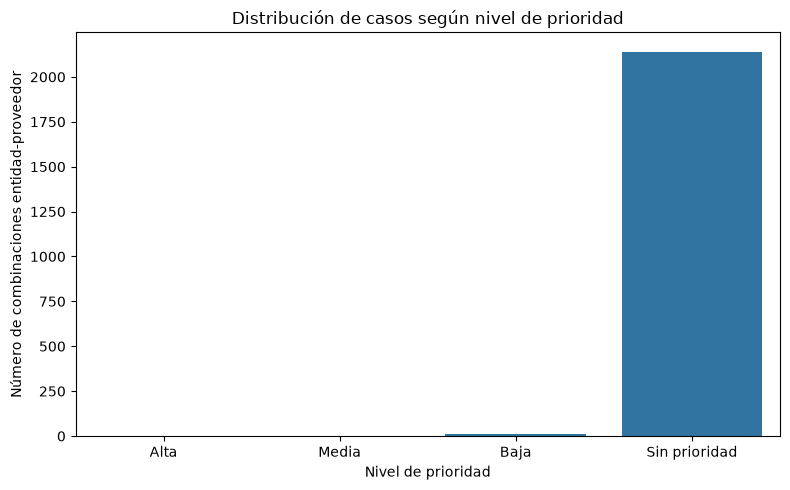

In [17]:
# Distribución de combinaciones según nivel de prioridad

plt.figure(figsize=(8, 5))

sns.countplot(
    data=tabla_indicadores,
    x="prioridad",
    order=["Alta", "Media", "Baja", "Sin prioridad"]
)

plt.title("Distribución de casos según nivel de prioridad")
plt.xlabel("Nivel de prioridad")
plt.ylabel("Número de combinaciones entidad-proveedor")

plt.tight_layout()

plt.savefig(
    ruta_figuras / "grafico_prioridades.png",
    dpi=300
)

plt.show()

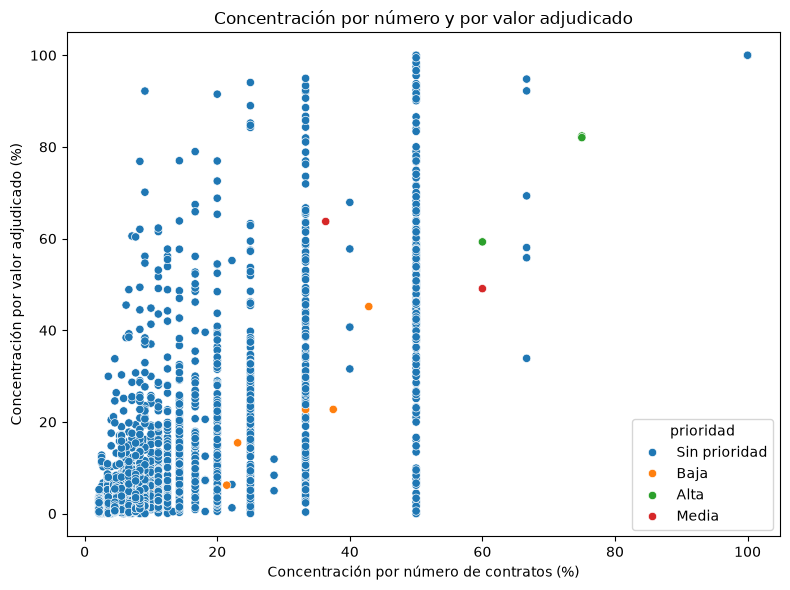

In [18]:
# Relación entre concentración por número de contratos
# y concentración por valor adjudicado

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=tabla_indicadores,
    x="concentracion_numero_pct",
    y="concentracion_valor_pct",
    hue="prioridad"
)

plt.title("Concentración por número y por valor adjudicado")
plt.xlabel("Concentración por número de contratos (%)")
plt.ylabel("Concentración por valor adjudicado (%)")

plt.tight_layout()

plt.savefig(
    ruta_figuras / "grafico_concentraciones.png",
    dpi=300
)

plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22152\3616174122.py:16: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_22152\3616174122.py:18: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig(
C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


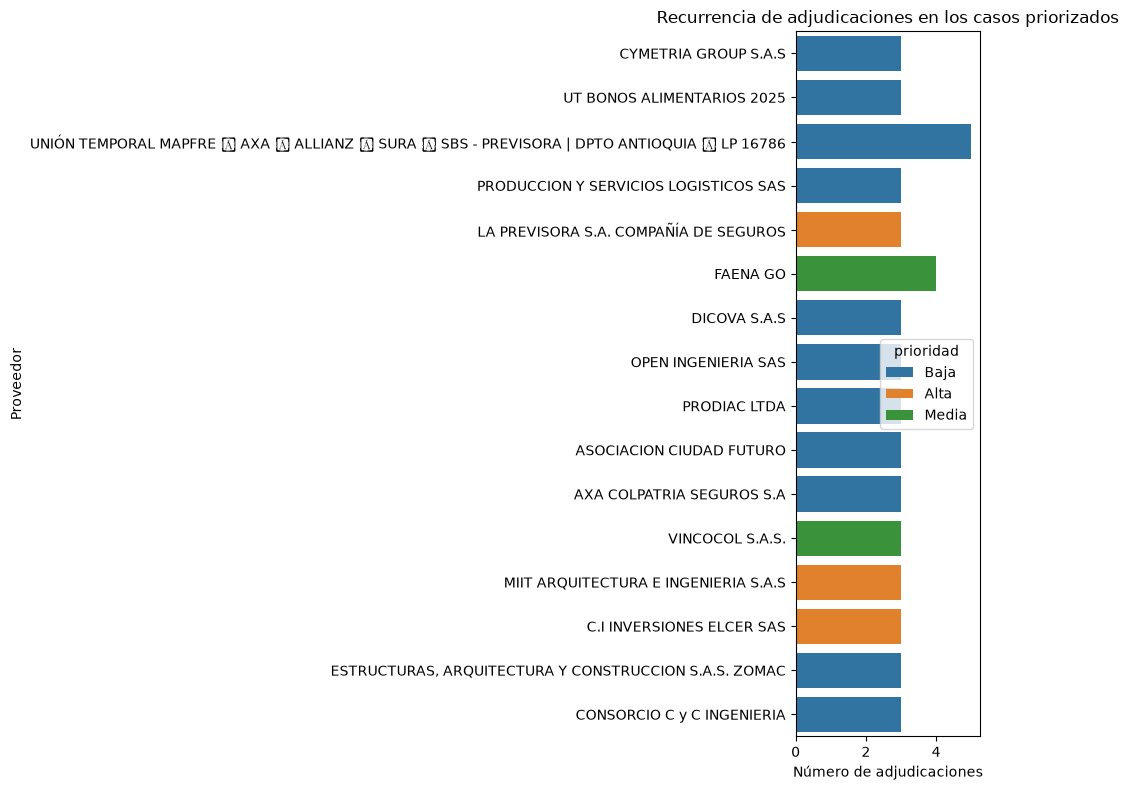

In [19]:
# Recurrencia de adjudicaciones entre los casos priorizados

plt.figure(figsize=(10, 8))

sns.barplot(
    data=casos_priorizados,
    x="recurrencia",
    y="proveedor",
    hue="prioridad"
)

plt.title("Recurrencia de adjudicaciones en los casos priorizados")
plt.xlabel("Número de adjudicaciones")
plt.ylabel("Proveedor")

plt.tight_layout()

plt.savefig(
    ruta_figuras / "grafico_recurrencia.png",
    dpi=300
)

plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22152\335169646.py:40: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_22152\335169646.py:43: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig(
C:\Users\Usuario\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


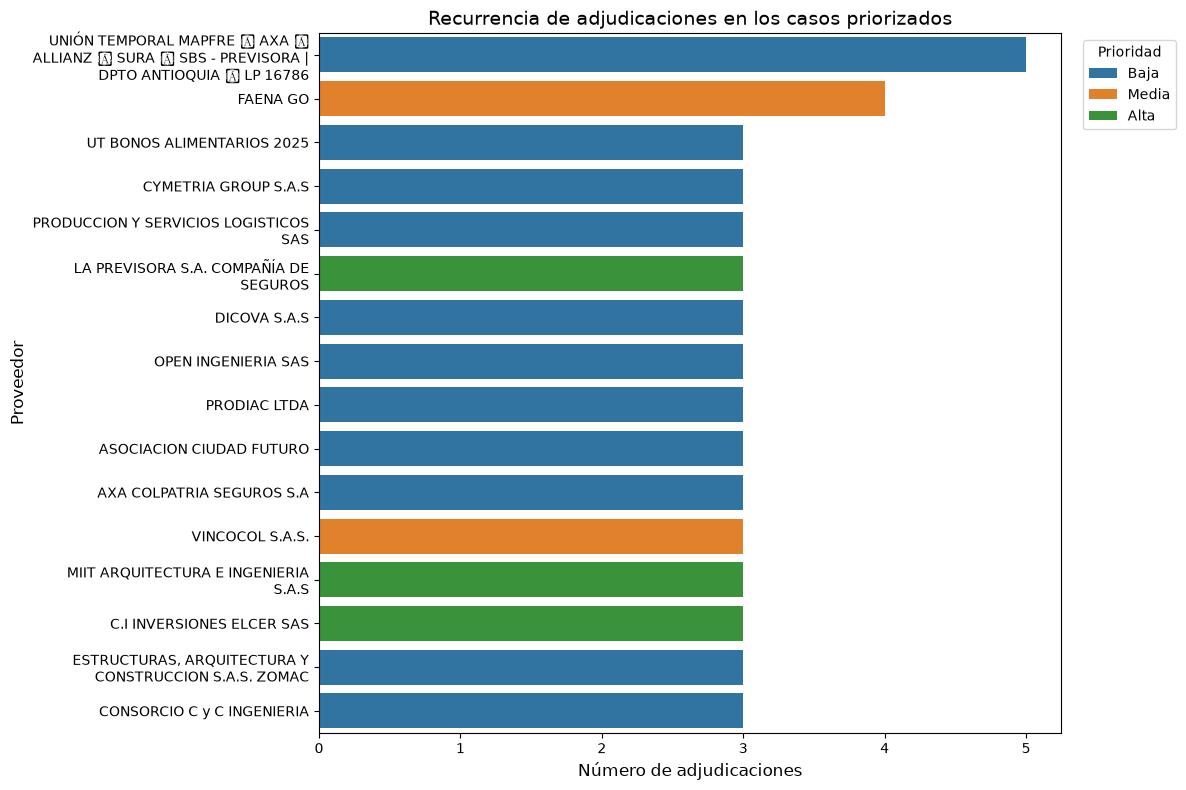

In [20]:
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns

# Copia para no modificar la tabla original
grafico_priorizados = casos_priorizados.copy()

# Crear una versión más corta del nombre del proveedor para mostrar en el gráfico
grafico_priorizados["proveedor_grafico"] = grafico_priorizados["proveedor"].apply(
    lambda x: textwrap.fill(str(x), width=35)
)

# Ordenar por recurrencia para mejorar la lectura
grafico_priorizados = grafico_priorizados.sort_values(
    by="recurrencia",
    ascending=False
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=grafico_priorizados,
    x="recurrencia",
    y="proveedor_grafico",
    hue="prioridad"
)

plt.title("Recurrencia de adjudicaciones en los casos priorizados", fontsize=14)
plt.xlabel("Número de adjudicaciones", fontsize=12)
plt.ylabel("Proveedor", fontsize=12)

# Mover la leyenda fuera del área del gráfico
plt.legend(
    title="Prioridad",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Ajustar márgenes
plt.tight_layout()

# Guardar evitando recortes
plt.savefig(
    ruta_figuras / "grafico_recurrencia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Preparar los indicadores de concentración para el boxplot

datos_boxplot = tabla_indicadores[
    [
        "concentracion_numero_pct",
        "concentracion_valor_pct"
    ]
].melt(
    var_name="indicador",
    value_name="porcentaje"
)

datos_boxplot.head()



,indicador,porcentaje
0,concentracion_numero_pct,25.0
1,concentracion_numero_pct,25.0
2,concentracion_numero_pct,25.0
3,concentracion_numero_pct,25.0
4,concentracion_numero_pct,50.0


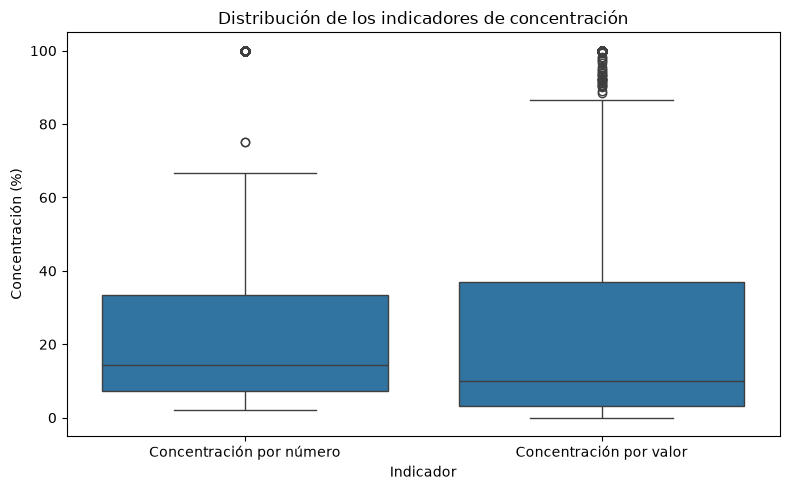

In [22]:
# Gráfico de cajas de los indicadores de concentración

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=datos_boxplot,
    x="indicador",
    y="porcentaje"
)

plt.title("Distribución de los indicadores de concentración")
plt.xlabel("Indicador")
plt.ylabel("Concentración (%)")

plt.xticks(
    ticks=[0, 1],
    labels=[
        "Concentración por número",
        "Concentración por valor"
    ]
)

plt.tight_layout()
plt.show()

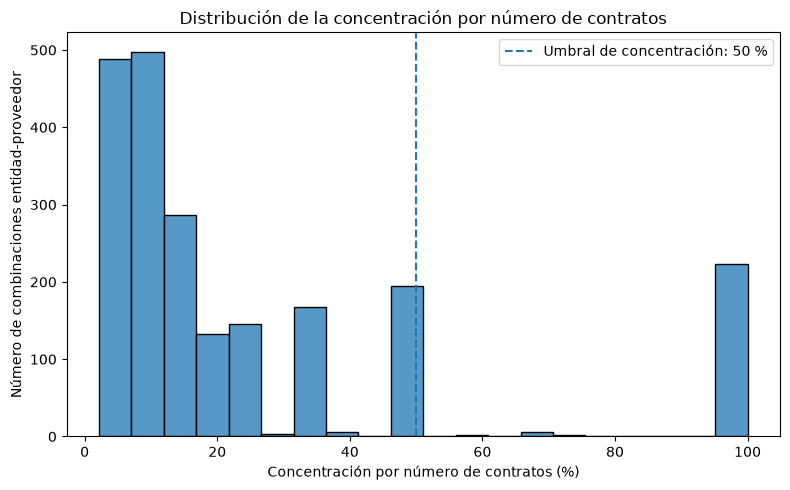

In [23]:
# Histograma de concentración por número de contratos

plt.figure(figsize=(8, 5))

sns.histplot(
    data=tabla_indicadores,
    x="concentracion_numero_pct",
    bins=20
)

# Línea de referencia del umbral utilizado
plt.axvline(
    x=50,
    linestyle="--",
    label="Umbral de concentración: 50 %"
)

plt.title("Distribución de la concentración por número de contratos")
plt.xlabel("Concentración por número de contratos (%)")
plt.ylabel("Número de combinaciones entidad-proveedor")

plt.legend()
plt.tight_layout()

plt.savefig(
    ruta_figuras / "histograma_concentracion_numero.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

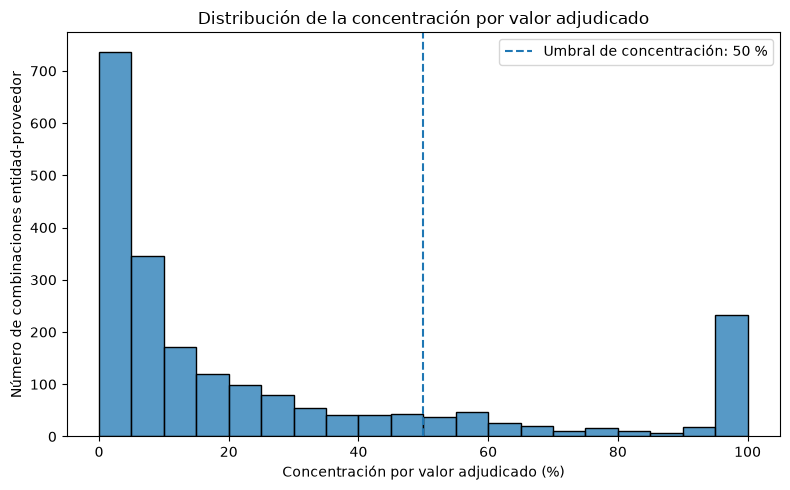

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=tabla_indicadores,
    x="concentracion_valor_pct",
    bins=20
)

plt.axvline(
    x=50,
    linestyle="--",
    label="Umbral de concentración: 50 %"
)

plt.title("Distribución de la concentración por valor adjudicado")
plt.xlabel("Concentración por valor adjudicado (%)")
plt.ylabel("Número de combinaciones entidad-proveedor")

plt.legend()
plt.tight_layout()
plt.show()